#  Load clean master data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

master_df = pd.read_csv('D:/Varanasi_Air_Quality/data/processed/master_clean.csv',
                         parse_dates=['Timestamp'])

print(" Master data loaded")
print(f"Total rows    : {len(master_df):,}")
print(f"Total columns : {master_df.shape[1]}")
print(f"Date range    : {master_df['Timestamp'].min()} → {master_df['Timestamp'].max()}")
print(f"Stations      : {master_df['station'].unique().tolist()}")

 Master data loaded
Total rows    : 35,040
Total columns : 29
Date range    : 2025-01-01 00:00:00 → 2025-12-31 23:00:00
Stations      : ['ardhali_bazar', 'bhelupur', 'bhu_iesd', 'maldahiya']


#  Basic statistics for all pollutants

In [3]:
pollutants = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)',
              'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)',
              'Benzene (µg/m³)', 'AT (°C)', 'RH (%)', 
              'WS (m/s)', 'SR (W/mt2)']

for station in master_df['station'].unique():
    df_s = master_df[master_df['station'] == station]
    print(f"\n{'='*55}")
    print(f"  STATION : {station.upper()}")
    print(f"{'='*55}")
    print(df_s[pollutants].describe().round(2))


  STATION : ARDHALI_BAZAR
       PM2.5 (µg/m³)  PM10 (µg/m³)  NO (µg/m³)  SO2 (µg/m³)  CO (mg/m³)  \
count        8607.00       8603.00     8760.00      8016.00     8621.00   
mean           31.82         69.01       12.67        13.25        0.25   
std            25.02         57.03       14.34         3.59        0.15   
min             2.00          3.25        0.12         0.70        0.00   
25%            15.75         31.33        4.30        11.72        0.18   
50%            25.25         50.00        5.60        13.69        0.21   
75%            40.75         87.25       11.28        14.54        0.28   
max           397.00        508.00      120.74       109.60        2.12   

       Ozone (µg/m³)  Benzene (µg/m³)  AT (°C)   RH (%)  WS (m/s)  SR (W/mt2)  
count        6139.00          8760.00  6167.00  6159.00   6128.00     8760.00  
mean           26.31             0.82    25.76    65.45      0.90      116.41  
std            12.88             0.42     6.74    17.34  

# Missing values remaining after imputation

In [4]:
print("MISSING VALUES REMAINING AFTER IMPUTATION")
print()

for station in master_df['station'].unique():
    df_s = master_df[master_df['station'] == station]
    print(f"\nStation : {station.upper()}")
    missing = df_s[pollutants].isnull().sum()
    missing_pct = (df_s[pollutants].isnull().sum() / len(df_s) * 100).round(1)
    summary = pd.DataFrame({
        'Missing Count' : missing,
        'Missing %'     : missing_pct
    })
    
    # Only show parameters that still have missing values
    summary = summary[summary['Missing Count'] > 0]
    if len(summary) == 0:
        print("  No missing values remaining ")
    else:
        print(summary)

MISSING VALUES REMAINING AFTER IMPUTATION


Station : ARDHALI_BAZAR
               Missing Count  Missing %
PM2.5 (µg/m³)            153        1.7
PM10 (µg/m³)             157        1.8
SO2 (µg/m³)              744        8.5
CO (mg/m³)               139        1.6
Ozone (µg/m³)           2621       29.9
AT (°C)                 2593       29.6
RH (%)                  2601       29.7
WS (m/s)                2632       30.0

Station : BHELUPUR
               Missing Count  Missing %
PM2.5 (µg/m³)           1237       14.1
PM10 (µg/m³)             136        1.6
CO (mg/m³)                20        0.2
Ozone (µg/m³)            554        6.3
AT (°C)                   59        0.7
RH (%)                    59        0.7
WS (m/s)                  71        0.8
SR (W/mt2)                20        0.2

Station : BHU_IESD
               Missing Count  Missing %
PM2.5 (µg/m³)           1151       13.1
PM10 (µg/m³)             715        8.2
CO (mg/m³)                16        0.2
Ozone (µg/m³


#  Which station has best and worst data quality

In [5]:
print("STATION DATA QUALITY RANKING")
print("="*55)
print("(Lower missing % = Better data quality)")
print()

quality = []
for station in master_df['station'].unique():
    df_s = master_df[master_df['station'] == station]
    total_missing = df_s[pollutants].isnull().sum().sum()
    total_values  = df_s[pollutants].size
    missing_pct   = round(total_missing / total_values * 100, 2)
    quality.append({
        'Station'        : station,
        'Total Missing'  : total_missing,
        'Missing %'      : missing_pct
    })
quality_df = pd.DataFrame(quality).sort_values('Missing %')
quality_df['Rank'] = range(1, 5)
quality_df['Quality'] = ['Best', 'Good', 'Fair', 'Worst']
print(quality_df.to_string(index=False))

STATION DATA QUALITY RANKING
(Lower missing % = Better data quality)

      Station  Total Missing  Missing %  Rank Quality
    maldahiya            593       0.62     1    Best
     bhelupur           2156       2.24     2    Good
     bhu_iesd           2603       2.70     3    Fair
ardhali_bazar          11640      12.08     4   Worst


# Monthly missing data pattern
Showing as percentage so it is easier to understand  

Was any sensor down for long periods in specific months?

In [6]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

check = {
    'ardhali_bazar' : ['Ozone (µg/m³)', 'AT (°C)', 
                        'RH (%)', 'WS (m/s)', 'SR (W/mt2)'],
    'bhelupur'      : ['PM2.5 (µg/m³)'],
    'bhu_iesd'      : ['PM2.5 (µg/m³)'],
}

for station, params in check.items():
    df_s = master_df[master_df['station'] == station]
    
    print(f"\n{'='*55}")
    print(f"  STATION : {station.upper()}")
    print(f"{'='*55}")
    
    for param in params:
        monthly = df_s.groupby('month')[param].apply(
            lambda x: round(x.isnull().sum() / len(x) * 100, 1)
        )
        monthly.index = month_names
        print(f"\n  {param} — missing % per month:")
        print(f"{monthly.to_string()}")


  STATION : ARDHALI_BAZAR

  Ozone (µg/m³) — missing % per month:
Jan      2.6
Feb      0.0
Mar      0.0
Apr      0.1
May      3.2
Jun      0.8
Jul      4.4
Aug     98.9
Sep     97.8
Oct    100.0
Nov     48.3
Dec      0.8

  AT (°C) — missing % per month:
Jan      1.5
Feb      0.0
Mar      0.3
Apr      0.0
May      1.6
Jun      0.1
Jul      2.7
Aug     99.1
Sep    100.0
Oct    100.0
Nov     48.1
Dec      0.0

  RH (%) — missing % per month:
Jan      1.5
Feb      0.0
Mar      0.3
Apr      0.0
May      1.6
Jun      0.1
Jul      2.7
Aug     99.1
Sep    100.0
Oct    100.0
Nov     48.1
Dec      1.1

  WS (m/s) — missing % per month:
Jan      2.8
Feb      0.0
Mar      0.5
Apr      0.1
May      2.8
Jun      1.0
Jul      3.1
Aug     99.3
Sep    100.0
Oct    100.0
Nov     48.1
Dec      0.8

  SR (W/mt2) — missing % per month:
Jan    0.0
Feb    0.0
Mar    0.0
Apr    0.0
May    0.0
Jun    0.0
Jul    0.0
Aug    0.0
Sep    0.0
Oct    0.0
Nov    0.0
Dec    0.0

  STATION : BHELUPUR

  PM2.5 (µg/m³)

# What Insights You Will Find
#### Insight 1 — Sensor downtime period
If AT, RH, WS, SR all show high missing values in the same months at Ardhali Bazar — you can confidently say the meteorological sensor unit was down during those months. 
#### Insight 2 — PM2.5 sensor reliability
If Bhelupur and BHU IESD show PM2.5 missing concentrated in specific months — those months' pollution data is incomplete and conclusions drawn from those months should be treated carefully.
#### Insight 3 — Impact on analysis
If the Ardhali Bazar met sensor was down during Winter months — your meteorological analysis for that station will be incomplete for the most critical season. This is important mention in limitations.
#### Insight 4 — Data quality comparison
Maldahiya and Bhelupur have relatively complete meteorological data — so analysis will be more reliable for those stations than Ardhali Bazar.

# Distribution of each pollutant using Histogram

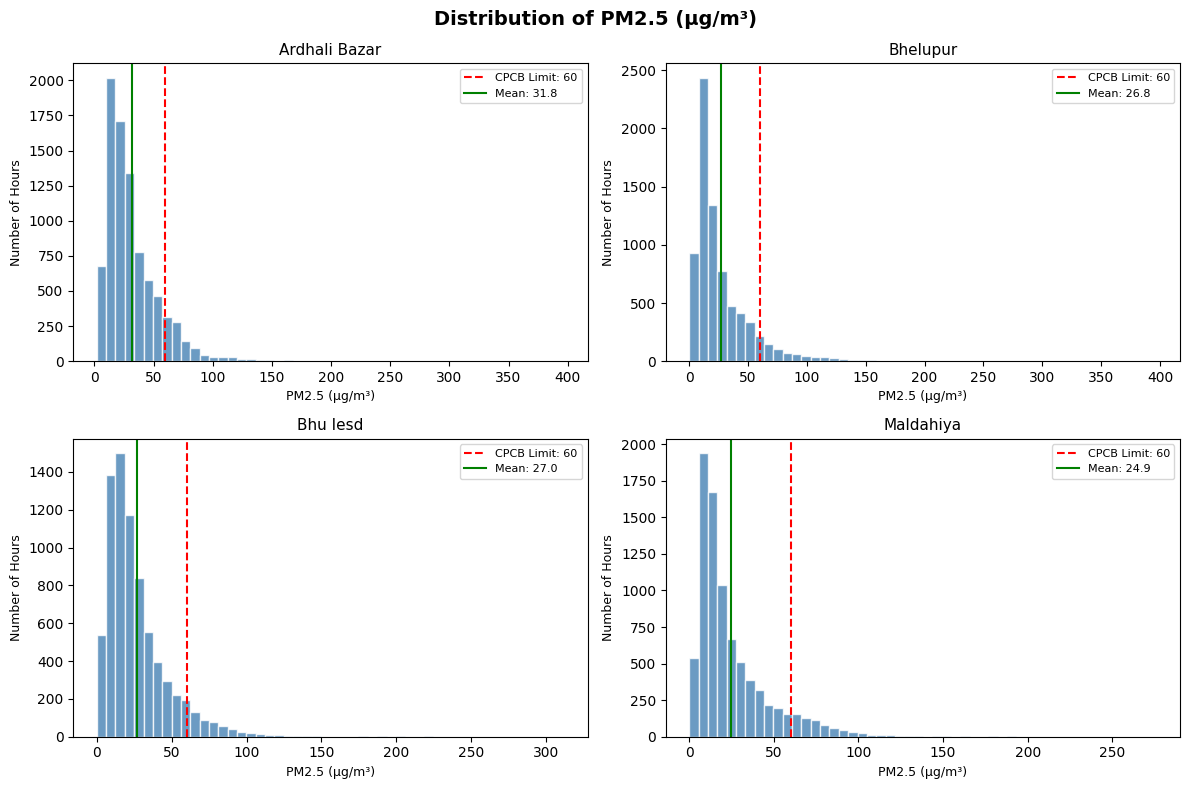

 Distribution chart saved for PM2.5 (µg/m³)


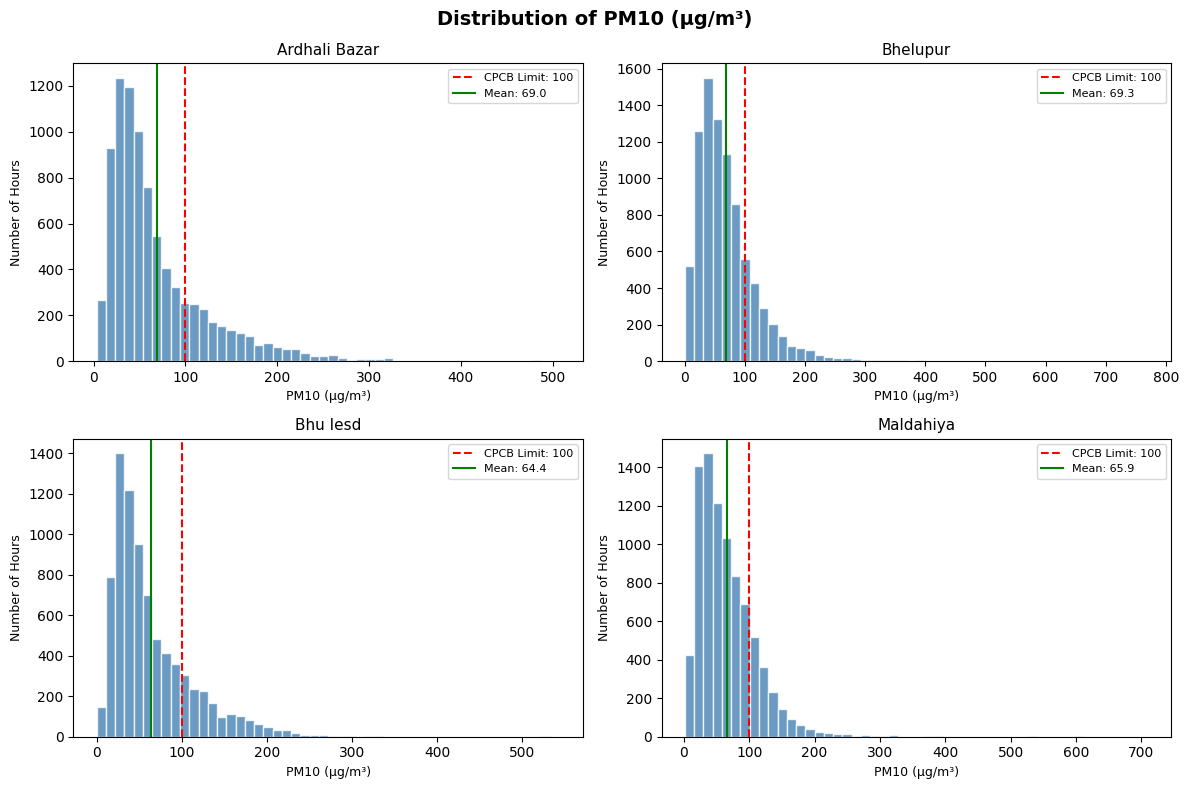

 Distribution chart saved for PM10 (µg/m³)


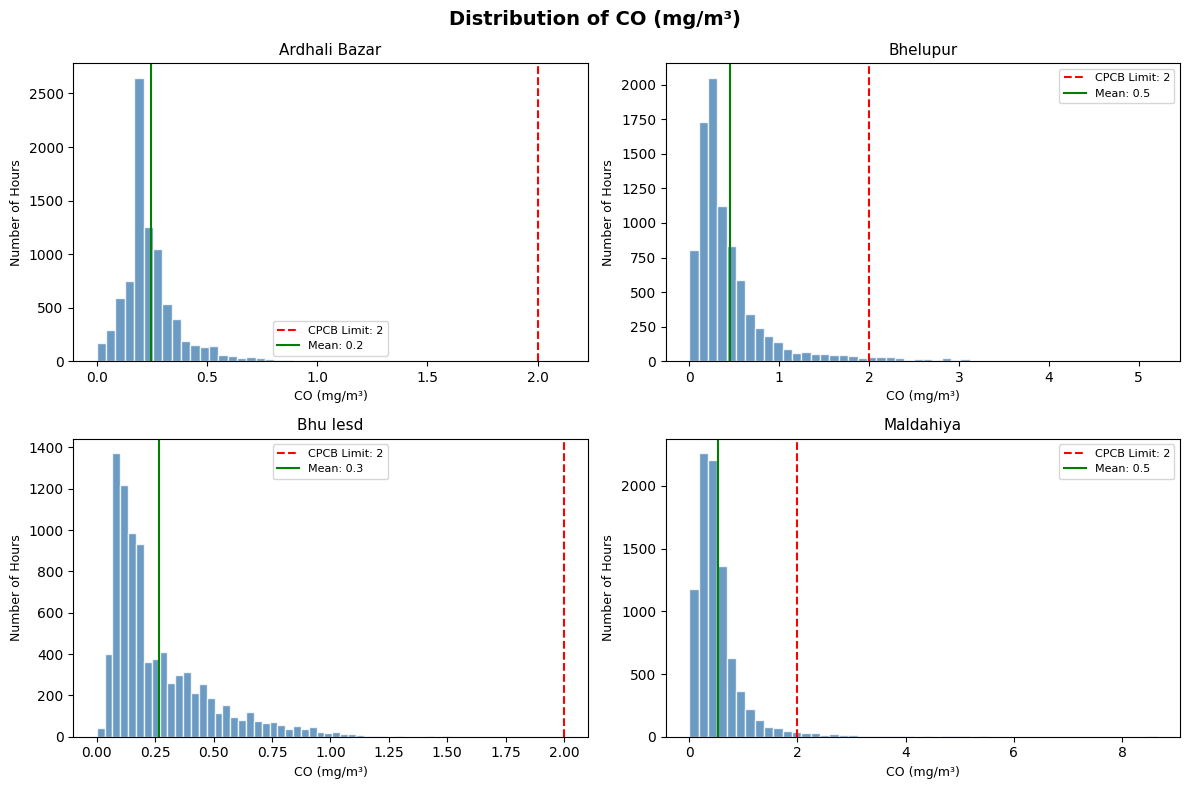

 Distribution chart saved for CO (mg/m³)


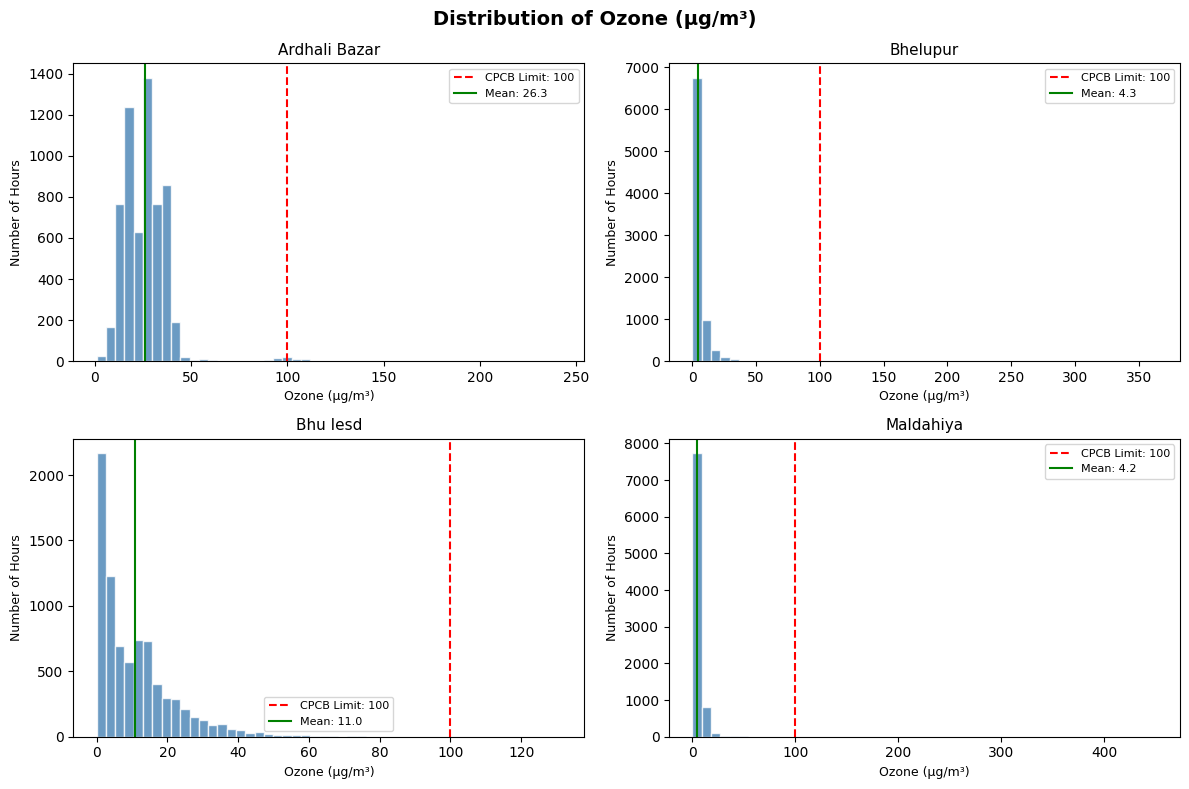

 Distribution chart saved for Ozone (µg/m³)


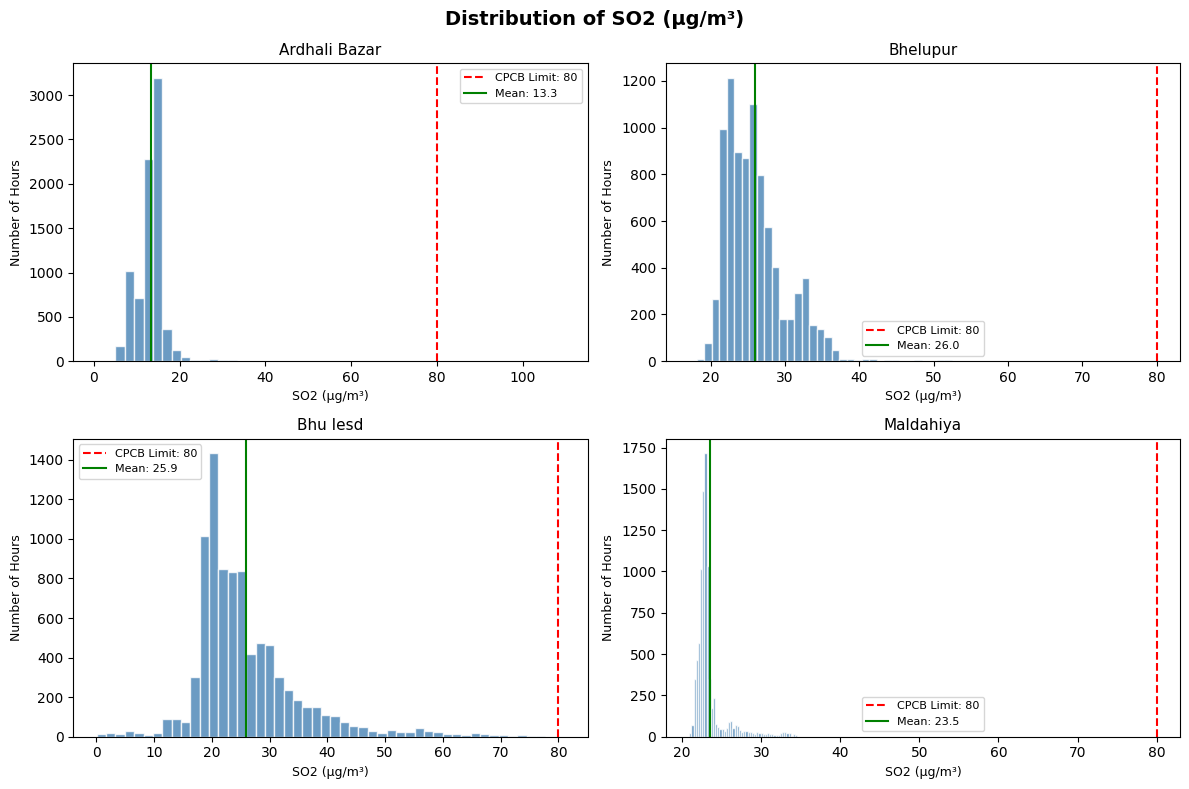

 Distribution chart saved for SO2 (µg/m³)


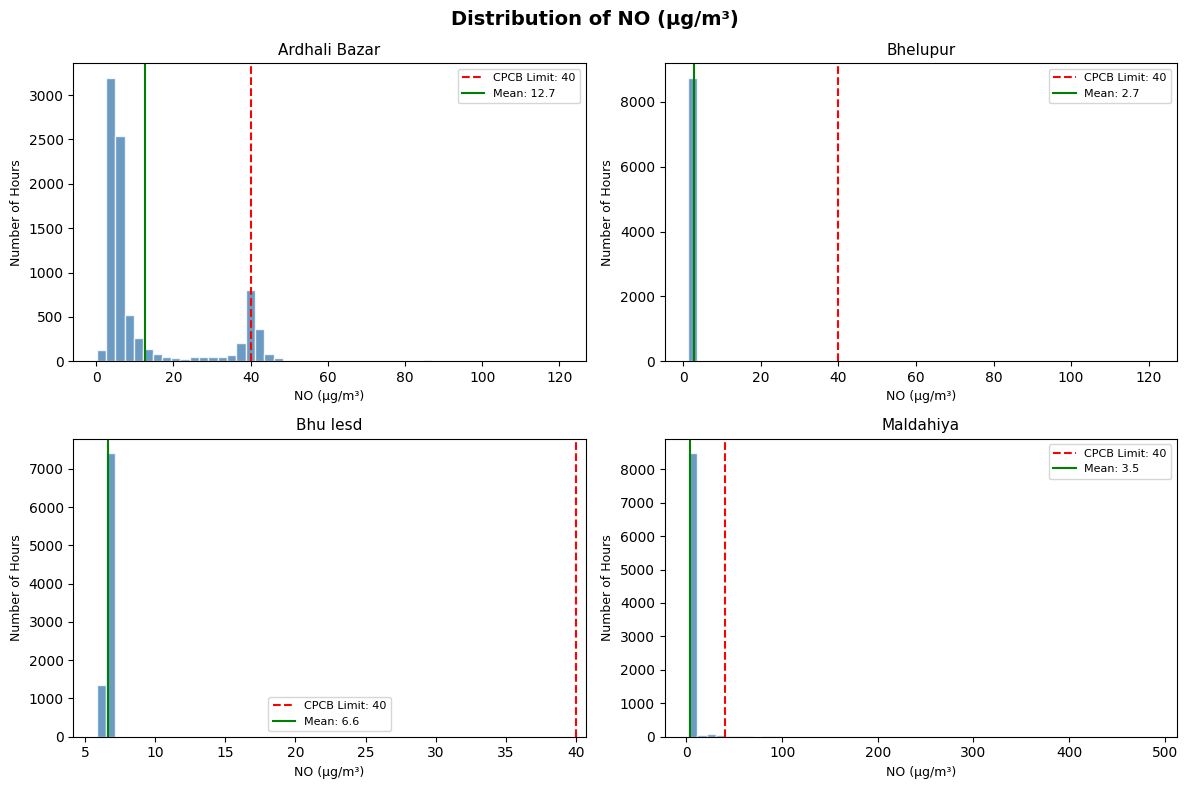

 Distribution chart saved for NO (µg/m³)


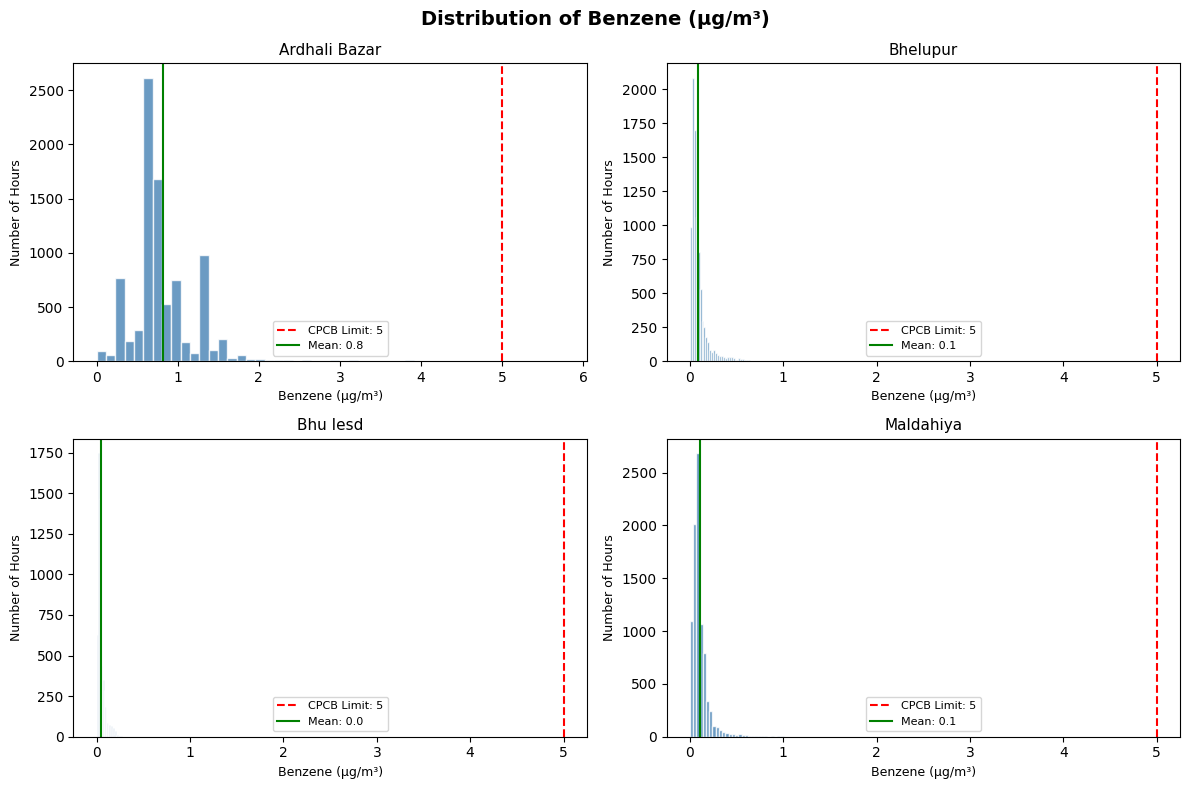

 Distribution chart saved for Benzene (µg/m³)


In [7]:
pollutants_to_plot = [
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'CO (mg/m³)',
    'Ozone (µg/m³)', 'SO2 (µg/m³)', 'NO (µg/m³)',
    'Benzene (µg/m³)'
]

# Create subfolder first
os.makedirs('D:/Varanasi_Air_Quality/outputs/charts/univariate', exist_ok=True)

stations_list = master_df['station'].unique()

for pollutant in pollutants_to_plot:

    # Creating one figure with 4 subplots - one per station
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'Distribution of {pollutant}', 
                 fontsize=14, fontweight='bold')

    # Flatten axes so we can loop through them easily
    axes = axes.flatten()

    for i, station in enumerate(stations_list):

        # Filter data for this station
        df_s = master_df[master_df['station'] == station][pollutant].dropna()

        # Plot histogram
        axes[i].hist(df_s, bins=50, color='steelblue', 
                     edgecolor='white', alpha=0.8)

        # Add CPCB limit line where applicable
        cpcb_limits = {
            'PM2.5 (µg/m³)' : 60,
            'PM10 (µg/m³)'  : 100,
            'CO (mg/m³)'    : 2,
            'Ozone (µg/m³)' : 100,
            'SO2 (µg/m³)'   : 80,
            'NO (µg/m³)'    : 40,
            'Benzene (µg/m³)': 5,
        }

        if pollutant in cpcb_limits:
            axes[i].axvline(x=cpcb_limits[pollutant], 
                           color='red', linestyle='--', 
                           linewidth=1.5,
                           label=f'CPCB Limit: {cpcb_limits[pollutant]}')
            axes[i].legend(fontsize=8)

        # Labels and title
        axes[i].set_title(station.replace('_', ' ').title(), fontsize=11)
        axes[i].set_xlabel(pollutant, fontsize=9)
        axes[i].set_ylabel('Number of Hours', fontsize=9)

        # Add mean line
        axes[i].axvline(x=df_s.mean(), color='green', 
                       linestyle='-', linewidth=1.5,
                       label=f'Mean: {df_s.mean():.1f}')
        axes[i].legend(fontsize=8)

    plt.tight_layout()

    # Save chart
    filename = pollutant.split(' ')[0].replace('.', '')
    plt.savefig(f'D:/Varanasi_Air_Quality/outputs/charts/univariate/distribution_{filename}.png', 
            dpi=150, bbox_inches='tight')
    plt.show()
    print(f" Distribution chart saved for {pollutant}")

# Time Series Plot of PM2.5 for all 4 stations

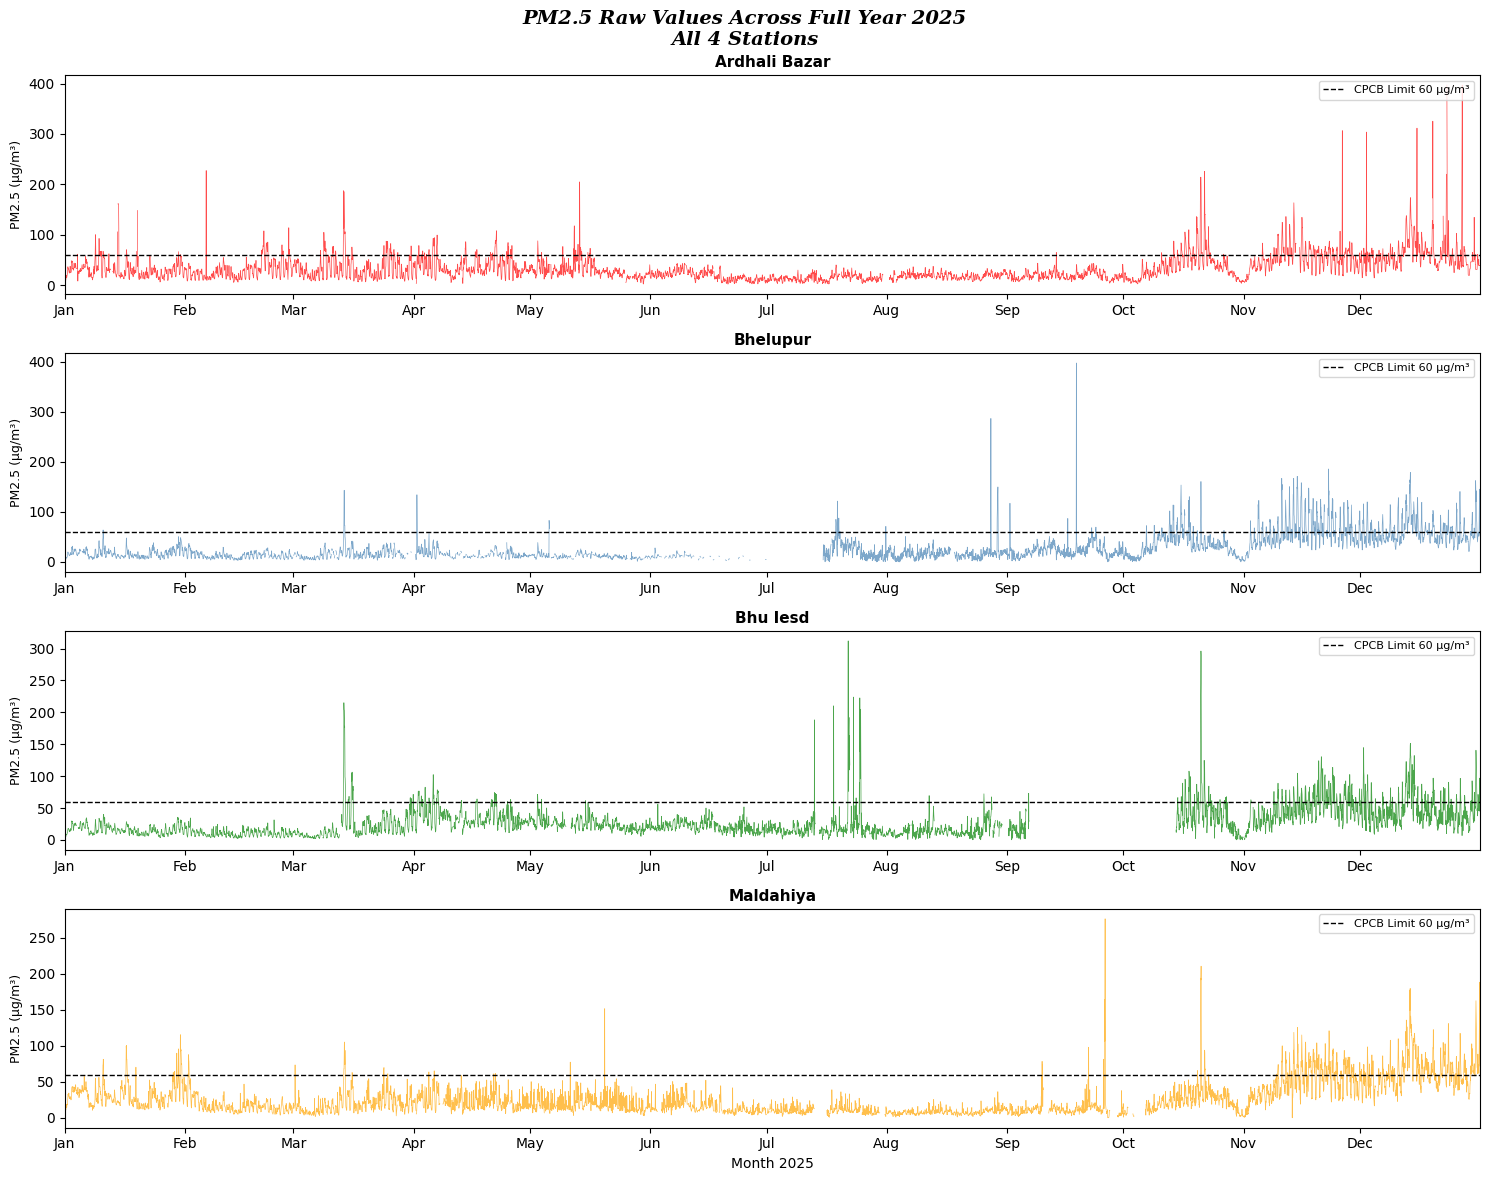

 PM2.5 time series chart saved


In [8]:
import matplotlib.dates as mdates

os.makedirs('D:/Varanasi_Air_Quality/outputs/charts/univariate', exist_ok=True)

# Color for each station
colors = {
    'bhelupur'     : 'steelblue',
    'ardhali_bazar': 'red',
    'bhu_iesd'     : 'green',
    'maldahiya'    : 'orange'
}

# Plot all 4 stations in one figure
fig, axes = plt.subplots(4, 1, figsize=(15, 12))
fig.suptitle('PM2.5 Raw Values Across Full Year 2025\nAll 4 Stations',
             fontsize=14, fontweight='bold',fontfamily='serif',fontstyle='italic')

for i, station in enumerate(master_df['station'].unique()):

    # Filter data for this station
    df_s = master_df[master_df['station'] == station]

    # Plot raw hourly PM2.5
    axes[i].plot(df_s['Timestamp'],
                 df_s['PM2.5 (µg/m³)'],
                 color=colors[station],
                 linewidth=0.5,        # thin line because 8760 points
                 alpha=0.7)

    # Add CPCB safe limit line
    axes[i].axhline(y=60,
                    color='black',
                    linestyle='--',
                    linewidth=1,
                    label='CPCB Limit 60 µg/m³')

    # Title and labels
    axes[i].set_title(station.replace('_',' ').title(), fontsize=11,fontweight='bold')
    axes[i].set_ylabel('PM2.5 (µg/m³)', fontsize=9)
    axes[i].legend(fontsize=8, loc='upper right')

    # Format x axis to show month names clearly
    axes[i].xaxis.set_major_locator(mdates.MonthLocator())           # Shows one tick per month
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))    # Shows month name like Jan, Feb, Mar instead of 2025-01-01
    axes[i].tick_params(axis='x', rotation=0)                        # Keeps month names horizontal not tilted

    # Add season labels on x axis
    axes[i].set_xlim(df_s['Timestamp'].min(),
                     df_s['Timestamp'].max())

# Only show x axis label on bottom plot
axes[3].set_xlabel('Month 2025', fontsize=10)

plt.tight_layout()
plt.savefig('D:/Varanasi_Air_Quality/outputs/charts/univariate/timeseries_pm25.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" PM2.5 time series chart saved")

# Monthly Average PM2.5 Trend (Line Chart)

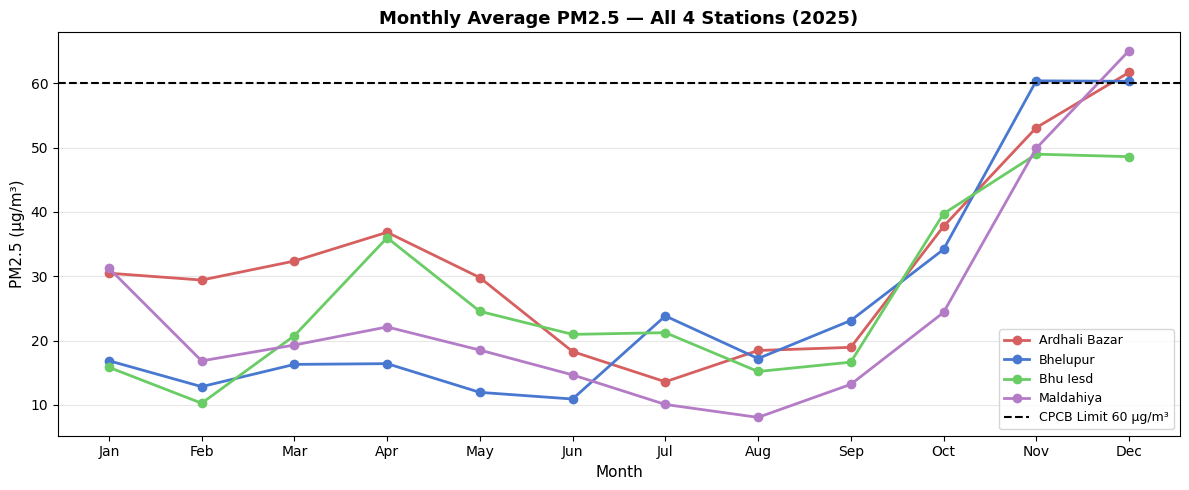

 Monthly average PM2.5 chart


In [9]:
os.makedirs('D:/varanasi_air_quality/outputs/charts/section2_univariate', exist_ok=True)

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

colors = {
    'bhelupur'     :'#4878CF',
    'ardhali_bazar': '#D65F5F',
    'bhu_iesd'     : '#6ACC65',
    'maldahiya'    : '#B47CC7'
}

fig, ax = plt.subplots(figsize=(12, 5))

for station in master_df['station'].unique():
    df_s = master_df[master_df['station'] == station]
    monthly_avg = df_s.groupby('month')['PM2.5 (µg/m³)'].mean()
    ax.plot(monthly_avg.index, monthly_avg.values,
            color=colors[station],
            marker='o',
            linewidth=2,
            label=station.replace('_',' ').title())

# CPCB safe limit line
ax.axhline(y=60, color='black', linestyle='--',
           linewidth=1.5, label='CPCB Limit 60 µg/m³')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Monthly Average PM2.5 — All 4 Stations (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section2_univariate/monthly_avg_pm25.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Monthly average PM2.5 chart")

# Monthly Average AQI (Bar Chart)

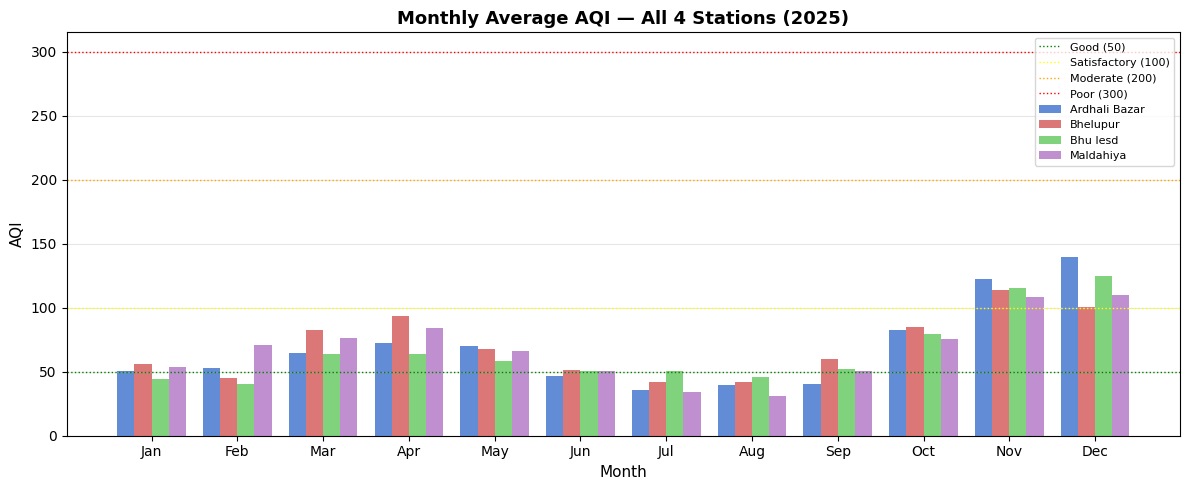

 Monthly average AQI chart


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

# Number of stations and bar width
stations = master_df['station'].unique()
n = len(stations)
bar_width = 0.2
x = np.arange(1, 13)

for i, station in enumerate(stations):
    df_s = master_df[master_df['station'] == station]
    monthly_aqi = df_s.groupby('month')['AQI'].mean()
    ax.bar(x + i * bar_width,
           monthly_aqi.values,
           width=bar_width,
           color=list(colors.values())[i],
           label=station.replace('_',' ').title(),
           alpha=0.85)

# AQI category lines
ax.axhline(y=50,  color='green',  linestyle=':', linewidth=1, label='Good (50)')
ax.axhline(y=100, color='yellow', linestyle=':', linewidth=1, label='Satisfactory (100)')
ax.axhline(y=200, color='orange', linestyle=':', linewidth=1, label='Moderate (200)')
ax.axhline(y=300, color='red',    linestyle=':', linewidth=1, label='Poor (300)')

ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(month_names)
ax.set_title('Monthly Average AQI — All 4 Stations (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('AQI', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/univariate/monthly_avg_aqi.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Monthly average AQI chart")

# 8 Hour Rolling Ozone - CPCB Standard

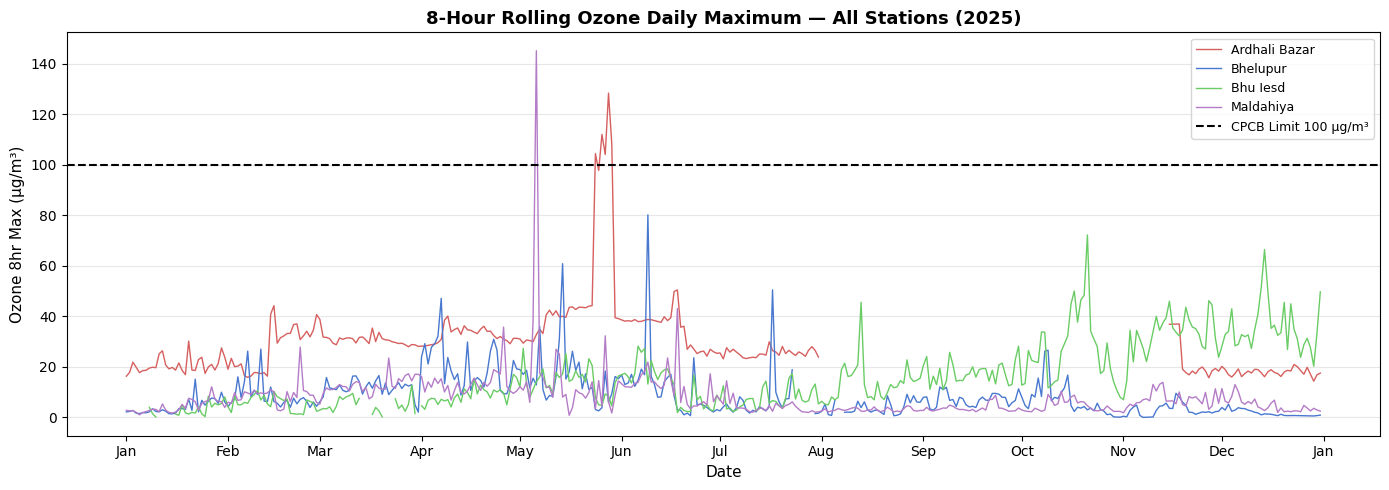

8hr rolling Ozone chart


In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

for station in master_df['station'].unique():
    df_s = master_df[master_df['station'] == station].copy()
    df_s = df_s.sort_values('Timestamp')

    # Calculate 8 hour rolling average
    df_s['ozone_8hr'] = df_s['Ozone (µg/m³)'].rolling(window=8).mean()

    # Daily maximum of 8hr rolling average
    daily_max = df_s.groupby(df_s['Timestamp'].dt.date)['ozone_8hr'].max()

    ax.plot(daily_max.index, daily_max.values,
            color=colors[station],
            linewidth=1,
            label=station.replace('_',' ').title())

ax.axhline(y=100, color='black', linestyle='--',
           linewidth=1.5, label='CPCB Limit 100 µg/m³')
ax.set_title('8-Hour Rolling Ozone Daily Maximum — All Stations (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Ozone 8hr Max (µg/m³)', fontsize=11)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
from pathlib import Path

output_dir = Path('D:/varanasi_air_quality/outputs/charts/section4_seasonal')
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(output_dir / 'ozone_8hr_rolling.png',
            dpi=150,
            bbox_inches='tight')
plt.savefig('D:/varanasi_air_quality/outputs/charts/section4_seasonal/ozone_8hr_rolling.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("8hr rolling Ozone chart")

# Station Ranking
#### Which station has worst PM2.5, PM10, AQI
#### What % of year each station spent in each AQI category

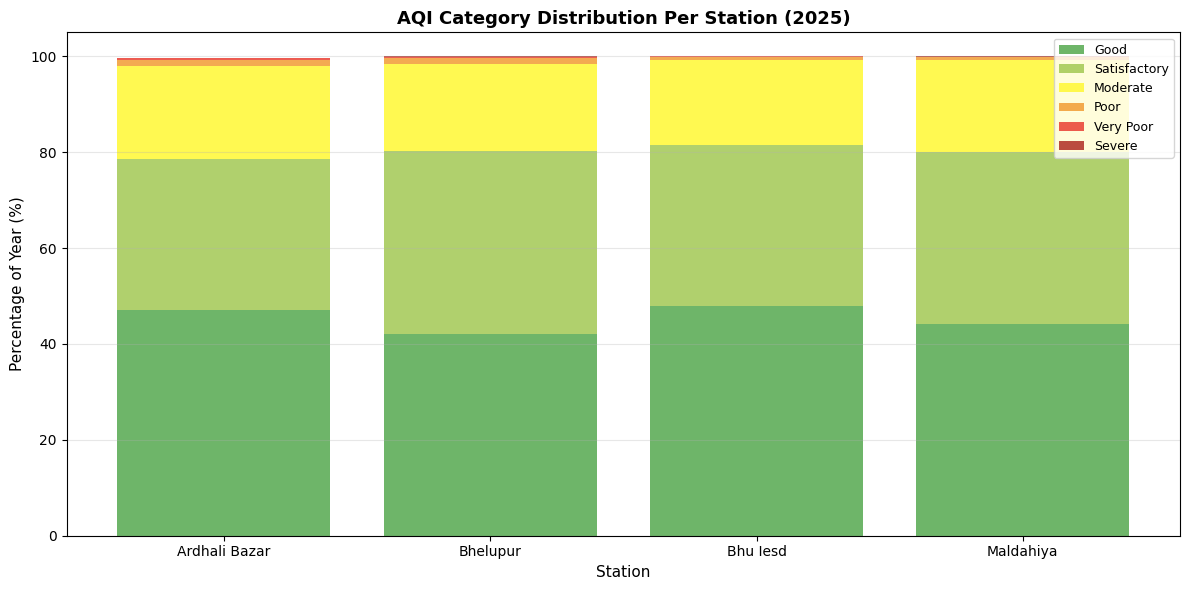

In [12]:
os.makedirs('D:/varanasi_air_quality/outputs/charts/section5_spatial', exist_ok=True)

aqi_colors = {
    'Good'        : '#55A84F',
    'Satisfactory': '#A3C853',
    'Moderate'    : '#FFF833',
    'Poor'        : '#F29C33',
    'Very Poor'   : '#E93F33',
    'Severe'      : '#AF2D24'
}

category_order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']

fig, ax = plt.subplots(figsize=(12, 6))

stations = master_df['station'].unique()
bar_bottoms = np.zeros(len(stations))
station_labels = [s.replace('_',' ').title() for s in stations]

for category in category_order:
    values = []
    for station in stations:
        df_s = master_df[master_df['station'] == station]
        pct = (df_s['AQI_Category'] == category).sum() / len(df_s) * 100
        values.append(pct)

    ax.bar(station_labels, values,
           bottom=bar_bottoms,
           color=aqi_colors[category],
           label=category,
           alpha=0.85)
    bar_bottoms += np.array(values)

ax.set_title('AQI Category Distribution Per Station (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Station', fontsize=11)
ax.set_ylabel('Percentage of Year (%)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section5_spatial/aqi_category_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()


# Monthly PM10 vs PM2.5 for all stations

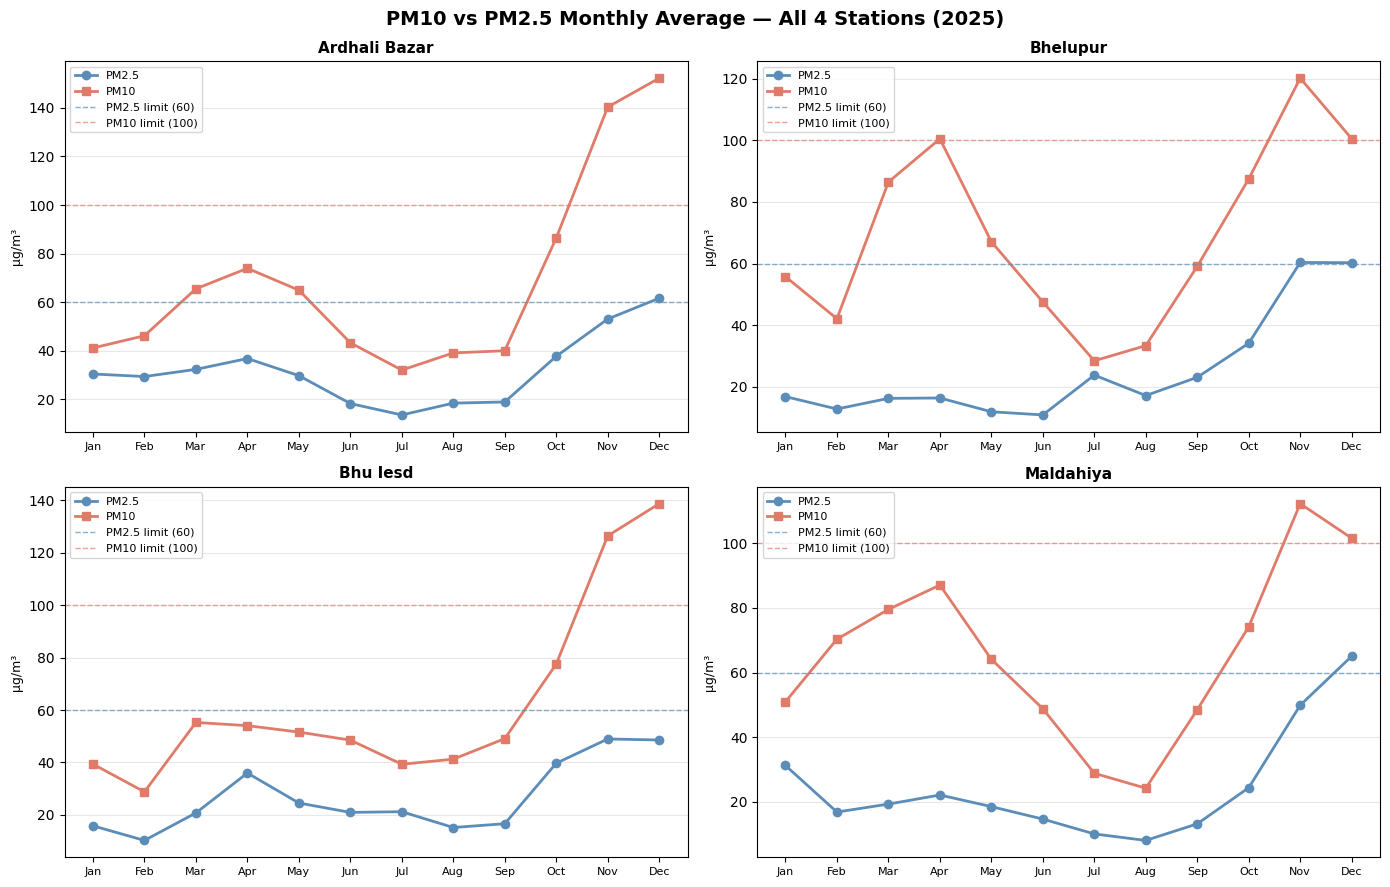

Chart 1 saved


In [13]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('PM10 vs PM2.5 Monthly Average — All 4 Stations (2025)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, station in enumerate(master_df['station'].unique()):
    df_s = master_df[master_df['station'] == station]

    pm25_monthly = df_s.groupby('month')['PM2.5 (µg/m³)'].mean()
    pm10_monthly = df_s.groupby('month')['PM10 (µg/m³)'].mean()

    axes[i].plot(pm25_monthly.index, pm25_monthly.values,
                 color='#5B8DB8', marker='o', linewidth=2, label='PM2.5')
    axes[i].plot(pm10_monthly.index, pm10_monthly.values,
                 color='#E07B6A', marker='s', linewidth=2, label='PM10')

    # CPCB limits
    axes[i].axhline(y=60,  color='#5B8DB8', linestyle='--', linewidth=1, alpha=0.7, label='PM2.5 limit (60)')
    axes[i].axhline(y=100, color='#E07B6A', linestyle='--', linewidth=1, alpha=0.7, label='PM10 limit (100)')

    axes[i].set_title(station.replace('_',' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xticks(range(1,13))
    axes[i].set_xticklabels(month_names, fontsize=8)
    axes[i].set_ylabel('µg/m³', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section5_spatial/pm10_vs_pm25_monthly.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

# PM10 vs PM2.5 COMPARATIVE ANALYSIS
#### Understanding why PM10 drives AQI more than PM2.5 in Varanasi

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

os.makedirs('D:/varanasi_air_quality/outputs/charts/pm10_analysis', exist_ok=True)

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

colors_station = {
    'bhelupur'     : '#5B8DB8',
    'ardhali_bazar': '#E07B6A',
    'bhu_iesd'     : '#6BAE75',
    'maldahiya'    : '#E6A817'
}

# ── CPCB Breakpoints for sub-index calculation ──────────────────
def pm25_subindex(cp):
    if np.isnan(cp): return np.nan
    if cp <= 30:  return cp * 50/30
    if cp <= 60:  return 50 + (cp-30) * 50/30
    if cp <= 90:  return 100 + (cp-60) * 100/30
    if cp <= 120: return 200 + (cp-90) * 100/30
    if cp <= 250: return 300 + (cp-120) * 100/130
    return min(400 + (cp-250) * 100/100, 500)

def pm10_subindex(cp):
    if np.isnan(cp): return np.nan
    if cp <= 50:  return cp * 50/50
    if cp <= 100: return 50 + (cp-50) * 50/50
    if cp <= 250: return 100 + (cp-100) * 100/150
    if cp <= 350: return 200 + (cp-250) * 100/100
    if cp <= 430: return 300 + (cp-350) * 100/80
    return min(400 + (cp-430) * 100/70, 500)

master_df['SI_PM2.5_calc'] = master_df['PM2.5 (µg/m³)'].apply(pm25_subindex)
master_df['SI_PM10_calc']  = master_df['PM10 (µg/m³)'].apply(pm10_subindex)

# Sub-index comparison — WHY PM10 dominates AQI

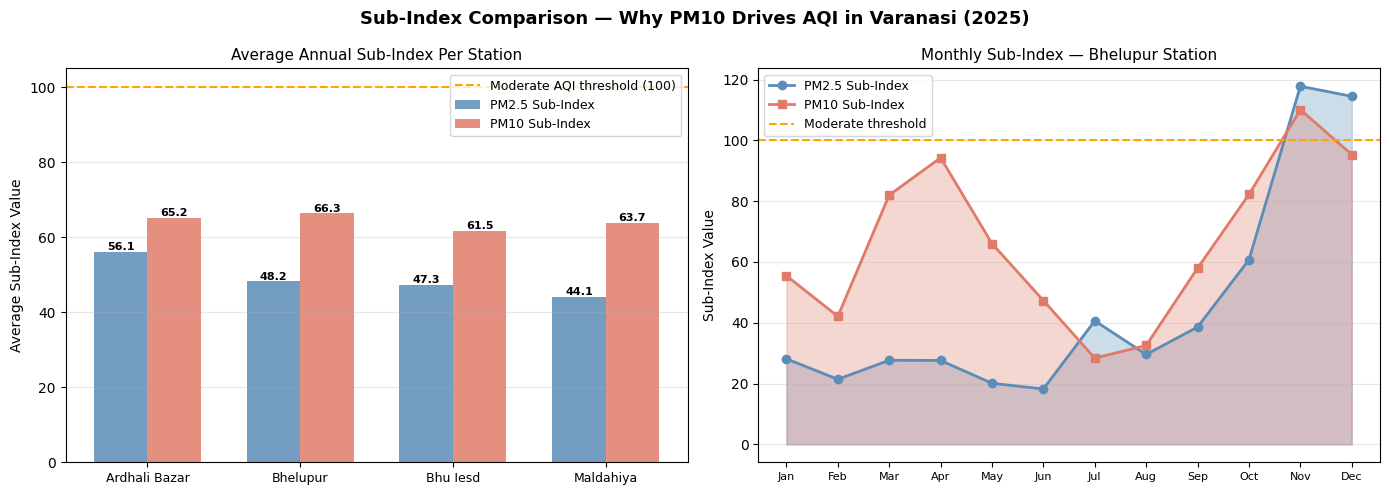

Chart 2 saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sub-Index Comparison — Why PM10 Drives AQI in Varanasi (2025)',
             fontsize=13, fontweight='bold')

# Left — average sub-index per station
stations = master_df['station'].unique()
pm25_si_avg = [master_df[master_df['station']==s]['SI_PM2.5_calc'].mean() for s in stations]
pm10_si_avg = [master_df[master_df['station']==s]['SI_PM10_calc'].mean() for s in stations]
labels = [s.replace('_',' ').title() for s in stations]

x = np.arange(len(labels))
width = 0.35

axes[0].bar(x - width/2, pm25_si_avg, width, label='PM2.5 Sub-Index',
            color='#5B8DB8', alpha=0.85)
axes[0].bar(x + width/2, pm10_si_avg, width, label='PM10 Sub-Index',
            color='#E07B6A', alpha=0.85)
axes[0].axhline(y=100, color='orange', linestyle='--', linewidth=1.5, label='Moderate AQI threshold (100)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel('Average Sub-Index Value', fontsize=10)
axes[0].set_title('Average Annual Sub-Index Per Station', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for j, (v1, v2) in enumerate(zip(pm25_si_avg, pm10_si_avg)):
    axes[0].text(j - width/2, v1 + 0.5, f'{v1:.1f}', ha='center', fontsize=8, fontweight='bold')
    axes[0].text(j + width/2, v2 + 0.5, f'{v2:.1f}', ha='center', fontsize=8, fontweight='bold')

# Right — monthly sub-index comparison (Bhelupur as example)
df_b = master_df[master_df['station'] == 'bhelupur']
pm25_si_m = df_b.groupby('month')['SI_PM2.5_calc'].mean()
pm10_si_m = df_b.groupby('month')['SI_PM10_calc'].mean()

axes[1].fill_between(pm25_si_m.index, pm25_si_m.values, alpha=0.3, color='#5B8DB8')
axes[1].fill_between(pm10_si_m.index, pm10_si_m.values, alpha=0.3, color='#E07B6A')
axes[1].plot(pm25_si_m.index, pm25_si_m.values, color='#5B8DB8', marker='o', linewidth=2, label='PM2.5 Sub-Index')
axes[1].plot(pm10_si_m.index, pm10_si_m.values, color='#E07B6A', marker='s', linewidth=2, label='PM10 Sub-Index')
axes[1].axhline(y=100, color='orange', linestyle='--', linewidth=1.5, label='Moderate threshold')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_names, fontsize=8)
axes[1].set_ylabel('Sub-Index Value', fontsize=10)
axes[1].set_title('Monthly Sub-Index — Bhelupur Station', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/pm10_analysis/subindex_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

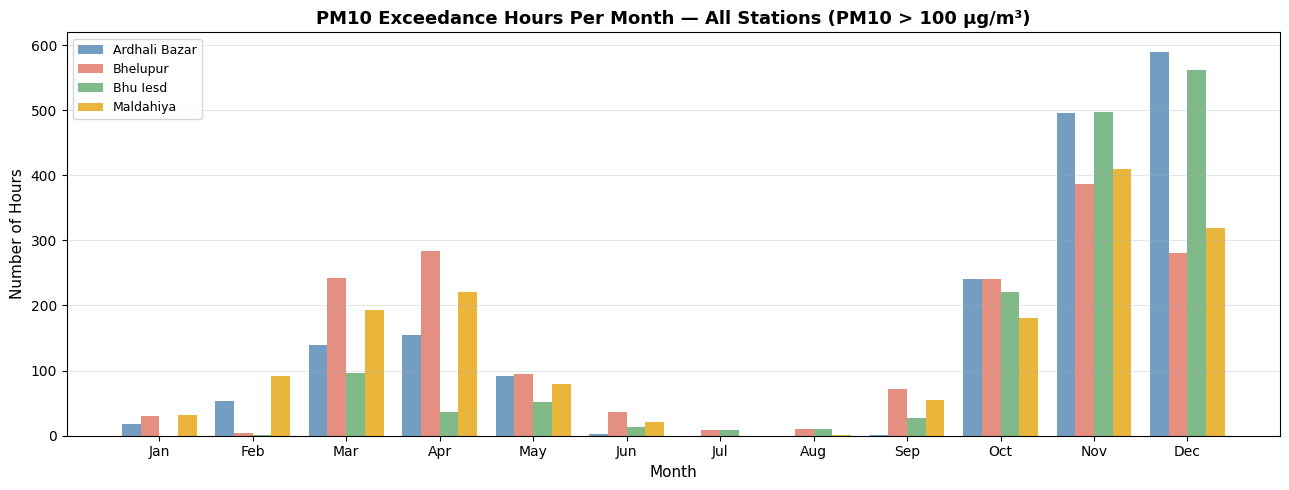

✓ Chart 3 saved


In [16]:
# ── CHART 3: PM10 exceedance hours per month per station ────────

fig, ax = plt.subplots(figsize=(13, 5))

stations_list = master_df['station'].unique()
n = len(stations_list)
bar_width = 0.2
x = np.arange(1, 13)

for i, station in enumerate(stations_list):
    df_s = master_df[master_df['station'] == station]
    # Count hours where PM10 exceeded CPCB limit of 100 µg/m³
    monthly_exceed = df_s.groupby('month')['PM10 (µg/m³)'].apply(
        lambda x: (x > 100).sum()
    )
    ax.bar(x + i * bar_width,
           monthly_exceed.values,
           width=bar_width,
           color=list(colors_station.values())[i],
           label=station.replace('_',' ').title(),
           alpha=0.85)

ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(month_names)
ax.set_title('PM10 Exceedance Hours Per Month — All Stations (PM10 > 100 µg/m³)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Number of Hours', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/pm10_analysis/pm10_exceedance_monthly.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 3 saved")